In [1]:
import pandas as pd

df = pd.read_csv('MicrobiomeWithMetadata.csv')
print(f"✅ Loaded! Shape: {df.shape}")
df.head()

✅ Loaded! Shape: (675, 6701)


,Diet,Source,Donor,CollectionMet,Sex,OTU0,OTU1,OTU2,OTU3,OTU4,...,OTU6686,OTU6687,OTU6688,OTU6689,OTU6690,OTU6691,OTU6692,OTU6693,OTU6694,OTU6695
0,0,0,0,0,0,1.560000e-11,4.720000e-11,1.230000e-11,4.520000e-11,2.720000e-11,...,6.660000e-11,3.020000e-11,4.420000e-11,7.310000e-11,7.770000e-11,4.330000e-11,5.440000e-11,8.720000e-11,2.710000e-11,4.970000e-11
1,0,1,0,0,0,2.360000e-11,9.530000e-11,3.330000e-11,2.670000e-11,2.020000e-11,...,3.260000e-12,5.390000e-11,4.730000e-11,2.600000e-11,4.240000e-11,6.550000e-11,4.850000e-11,8.380000e-11,3.500000e-11,7.620000e-11
2,0,2,0,1,0,6.770000e-11,3.680000e-11,8.020000e-11,5.490000e-11,1.340000e-11,...,7.230000e-11,6.300000e-12,7.060000e-11,8.310000e-11,3.310000e-11,7.380000e-11,4.450000e-11,9.650000e-12,7.880000e-11,3.990000e-11
3,0,2,0,0,0,5.520000e-11,9.890000e-11,4.580000e-11,3.540000e-11,2.090000e-11,...,9.100000e-11,2.940000e-11,1.000000e-10,9.820000e-11,8.540000e-11,9.730000e-11,2.960000e-11,8.580000e-13,5.880000e-11,5.510000e-11
4,0,3,0,0,0,5.240000e-11,6.340000e-11,2.350000e-11,7.470000e-11,2.490000e-11,...,1.500000e-11,4.900000e-11,8.110000e-12,4.670000e-11,8.270000e-11,4.630000e-11,1.600000e-11,5.550000e-11,7.840000e-11,8.560000e-11


In [2]:
# Check metadata columns
metadata_cols = ['Diet', 'Source', 'Donor', 'CollectionMet', 'Sex']

for col in metadata_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


Diet:
Diet
0    389
1    269
4      9
5      6
2      1
3      1
Name: count, dtype: int64

Source:
Source
4     461
12     42
2      23
1      19
9      19
0      18
3      18
7      16
6      15
8      13
5      12
10     12
11      7
Name: count, dtype: int64

Donor:
Donor
0    313
3    151
4     92
1     64
5     46
2      6
6      3
Name: count, dtype: int64

CollectionMet:
CollectionMet
0    594
1     81
Name: count, dtype: int64

Sex:
Sex
0    621
1     54
Name: count, dtype: int64


In [3]:
# Separate metadata and OTU table
metadata_cols = ['Diet', 'Source', 'Donor', 'CollectionMet', 'Sex']
otu_cols = [col for col in df.columns if col.startswith('OTU')]

metadata = df[metadata_cols]
otu_table = df[otu_cols]

# Keep only top 50 most abundant OTUs (makes processing fast)
top50 = otu_table.mean().sort_values(ascending=False).head(50).index.tolist()
otu_top50 = otu_table[top50]

print(f"✅ OTU table shape: {otu_table.shape}")
print(f"✅ Top 50 OTUs selected")
print(f"✅ Top 5 most abundant: {top50[:5]}")

✅ OTU table shape: (675, 6696)
✅ Top 50 OTUs selected
✅ Top 5 most abundant: ['OTU4496', 'OTU4154', 'OTU3857', 'OTU618', 'OTU5948']


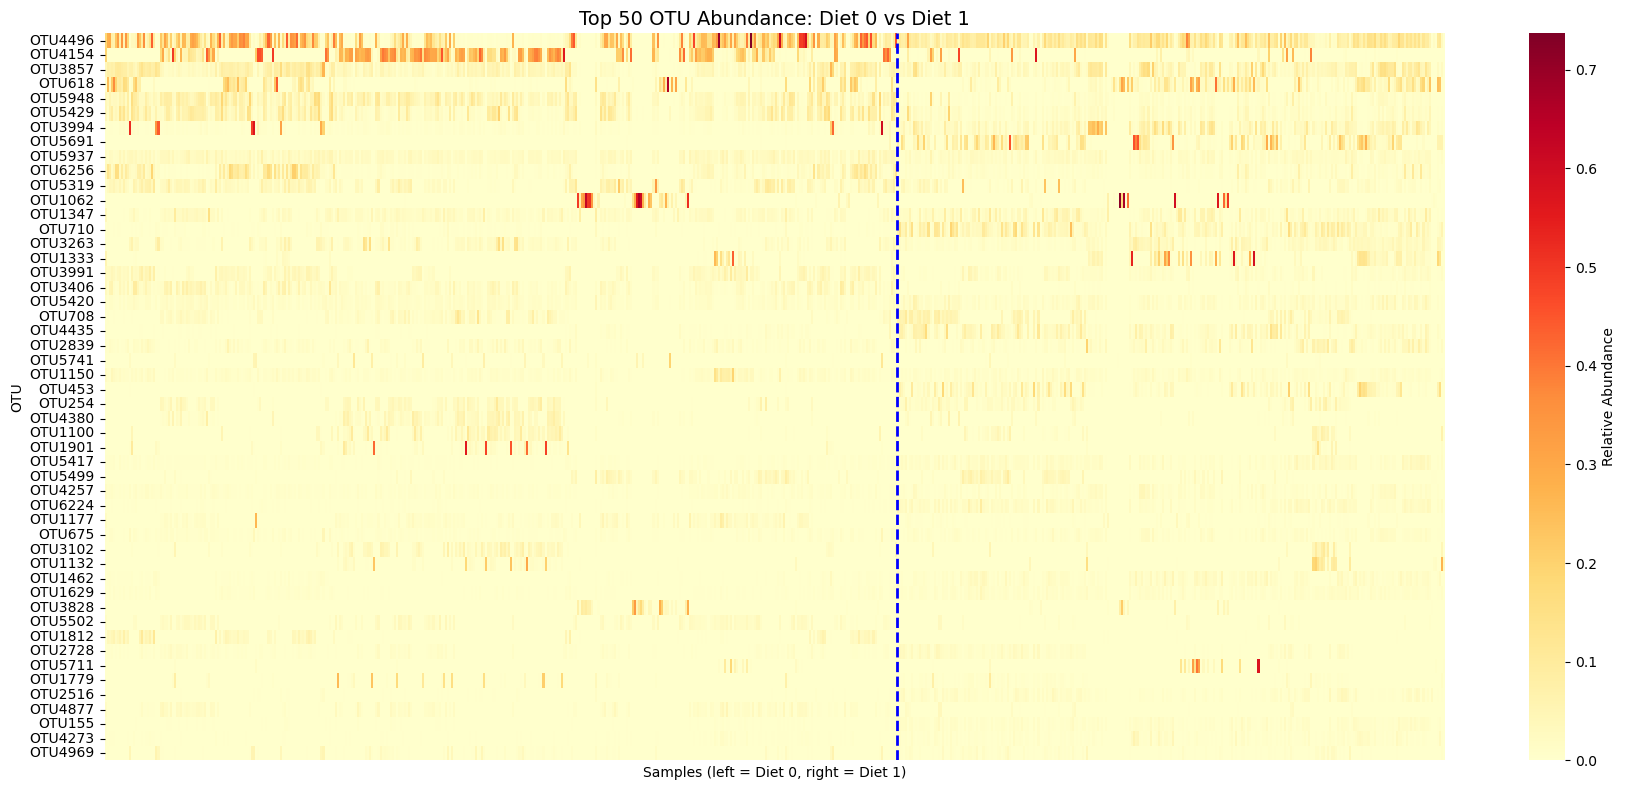

 Heatmap saved!


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter Diet 0 and Diet 1 samples only
diet_filter = df['Diet'].isin([0, 1])
otu_filtered = otu_top50[diet_filter]
diet_labels = metadata['Diet'][diet_filter]

# Sort by diet group
sort_idx = diet_labels.sort_values().index
otu_sorted = otu_filtered.loc[sort_idx]
diet_sorted = diet_labels.loc[sort_idx]

# Plot heatmap
plt.figure(figsize=(18, 8))
sns.heatmap(
    otu_sorted.T,
    cmap='YlOrRd',
    xticklabels=False,
    yticklabels=True,
    cbar_kws={'label': 'Relative Abundance'}
)

# Add diet group label
plt.axvline(x=(diet_sorted == 0).sum(), color='blue', linewidth=2, linestyle='--', label='Diet 0 | Diet 1')
plt.title('Top 50 OTU Abundance: Diet 0 vs Diet 1', fontsize=14)
plt.xlabel('Samples (left = Diet 0, right = Diet 1)')
plt.ylabel('OTU')
plt.tight_layout()
plt.savefig('heatmap_diet.png')
plt.show()
print(" Heatmap saved!")

In [5]:
from scipy import stats
import numpy as np

# Split into Diet 0 and Diet 1
diet0 = otu_top50[df['Diet'] == 0]
diet1 = otu_top50[df['Diet'] == 1]

# Mann-Whitney U test for each OTU
results = []
for otu in otu_top50.columns:
    stat, pval = stats.mannwhitneyu(diet0[otu], diet1[otu], alternative='two-sided')
    results.append({
        'OTU': otu,
        'mean_diet0': diet0[otu].mean(),
        'mean_diet1': diet1[otu].mean(),
        'pvalue': pval
    })

results_df = pd.DataFrame(results)

# Add fold change and significance
results_df['fold_change'] = results_df['mean_diet1'] / (results_df['mean_diet0'] + 1e-12)
results_df['log2_fc'] = np.log2(results_df['fold_change'])
results_df['significant'] = results_df['pvalue'] < 0.05
results_df = results_df.sort_values('pvalue')

print("✅ Statistical test done!")
print(f"\nSignificant OTUs (p < 0.05): {results_df['significant'].sum()} out of 50")
print("\nTop 10 most significantly different OTUs:")
print(results_df.head(10)[['OTU', 'mean_diet0', 'mean_diet1', 'pvalue', 'log2_fc']])

✅ Statistical test done!

Significant OTUs (p < 0.05): 36 out of 50

Top 10 most significantly different OTUs:
        OTU  mean_diet0  mean_diet1        pvalue   log2_fc
24   OTU453    0.000181    0.023666  1.435260e-58  7.033624
47   OTU155    0.001240    0.008192  4.476955e-57  2.724405
13   OTU710    0.002812    0.037125  2.710054e-56  3.722601
7   OTU5691    0.000207    0.051980  6.534136e-49  7.969382
17  OTU3406    0.019349    0.001815  3.069211e-48 -3.413946
45  OTU2516    0.001082    0.008631  1.980267e-46  2.995755
32  OTU6224    0.001502    0.013427  1.924891e-42  3.159698
4   OTU5948    0.045953    0.009794  1.684200e-41 -2.230115
37  OTU1462    0.001910    0.011824  5.663924e-41  2.629805
20  OTU4435    0.002199    0.024354  2.345032e-38  3.469272


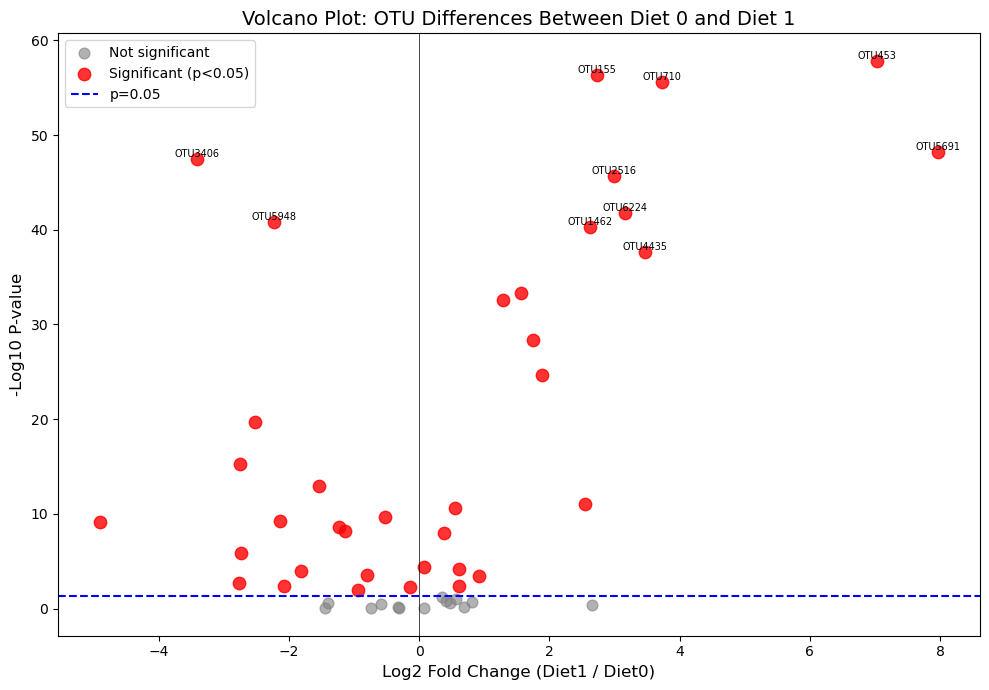

✅ Volcano plot saved!


In [6]:
plt.figure(figsize=(10, 7))

# Non-significant OTUs
ns = results_df[~results_df['significant']]
plt.scatter(ns['log2_fc'], -np.log10(ns['pvalue']),
            color='grey', alpha=0.6, label='Not significant', s=60)

# Significant OTUs
sig = results_df[results_df['significant']]
plt.scatter(sig['log2_fc'], -np.log10(sig['pvalue']),
            color='red', alpha=0.8, label='Significant (p<0.05)', s=80)

# Label top 10
for _, row in results_df.head(10).iterrows():
    plt.annotate(row['OTU'],
                xy=(row['log2_fc'], -np.log10(row['pvalue'])),
                fontsize=7, ha='center', va='bottom')

plt.axhline(y=-np.log10(0.05), color='blue', linestyle='--', label='p=0.05')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Log2 Fold Change (Diet1 / Diet0)', fontsize=12)
plt.ylabel('-Log10 P-value', fontsize=12)
plt.title('Volcano Plot: OTU Differences Between Diet 0 and Diet 1', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('volcano_plot.png')
plt.show()
print("✅ Volcano plot saved!")

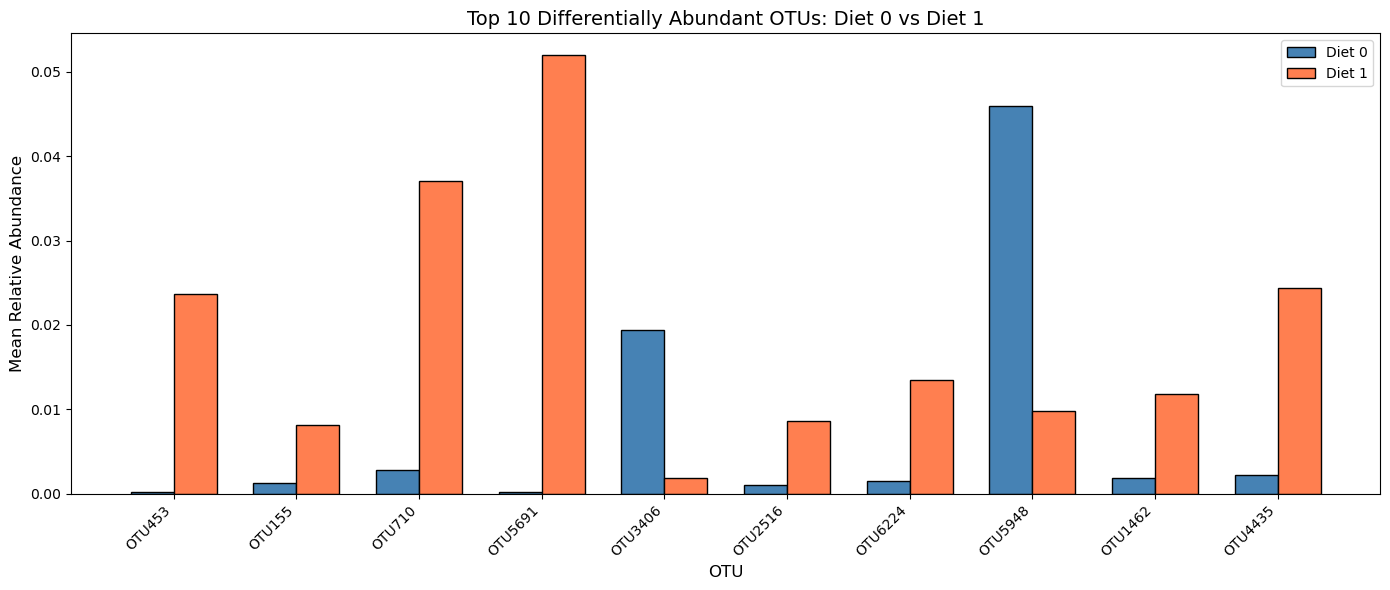

 Bar plot saved!


In [7]:
top10_sig = results_df.head(10)

x = range(len(top10_sig))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar([i - width/2 for i in x], top10_sig['mean_diet0'],
               width, label='Diet 0', color='steelblue', edgecolor='black')
bars2 = ax.bar([i + width/2 for i in x], top10_sig['mean_diet1'],
               width, label='Diet 1', color='coral', edgecolor='black')

ax.set_xlabel('OTU', fontsize=12)
ax.set_ylabel('Mean Relative Abundance', fontsize=12)
ax.set_title('Top 10 Differentially Abundant OTUs: Diet 0 vs Diet 1', fontsize=14)
ax.set_xticks(list(x))
ax.set_xticklabels(top10_sig['OTU'], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('top10_otus_barplot.png')
plt.show()
print(" Bar plot saved!")

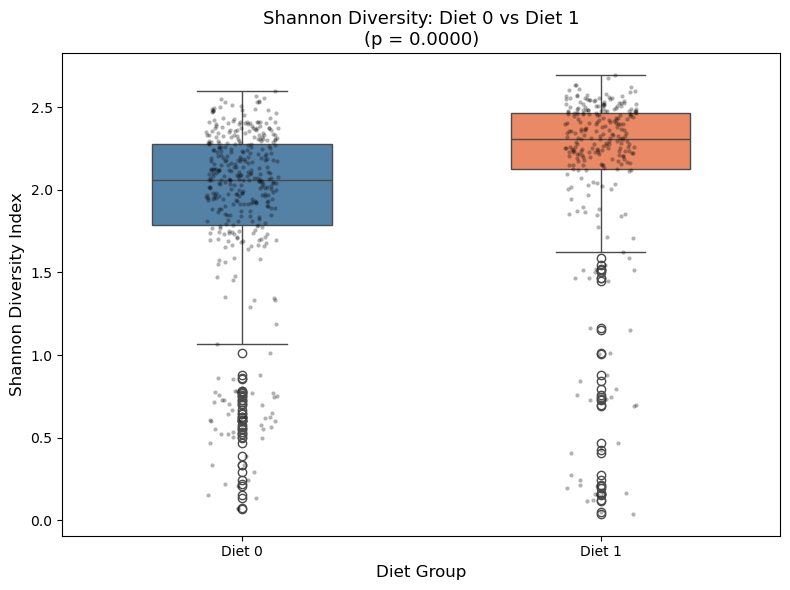

✅ Diversity plot saved!
   Diet 0 mean diversity: 1.9009
   Diet 1 mean diversity: 2.1043
   p-value: 0.0000


In [9]:
from scipy.stats import mannwhitneyu

# Shannon diversity index
def shannon_diversity(row):
    row = row[row > 0]
    return -np.sum(row * np.log(row))

df_diversity = df[df['Diet'].isin([0, 1])].copy()
otu_diversity = otu_top50[df['Diet'].isin([0, 1])]

df_diversity['shannon'] = otu_diversity.apply(shannon_diversity, axis=1).values

# Plot - fixed version
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_diversity,
    x='Diet',
    y='shannon',
    hue='Diet',        # ← fix
    palette=['steelblue', 'coral'],
    width=0.5,
    legend=False       # ← fix
)
sns.stripplot(
    data=df_diversity,
    x='Diet',
    y='shannon',
    color='black',
    alpha=0.3,
    size=3
)

# Stats
d0_shannon = df_diversity[df_diversity['Diet'] == 0]['shannon']
d1_shannon = df_diversity[df_diversity['Diet'] == 1]['shannon']
stat, pval = mannwhitneyu(d0_shannon, d1_shannon)

plt.title(f'Shannon Diversity: Diet 0 vs Diet 1\n(p = {pval:.4f})', fontsize=13)
plt.xlabel('Diet Group', fontsize=12)
plt.ylabel('Shannon Diversity Index', fontsize=12)
plt.xticks([0, 1], ['Diet 0', 'Diet 1'])
plt.tight_layout()
plt.savefig('diversity_boxplot.png')
plt.show()
print(f"✅ Diversity plot saved!")
print(f"   Diet 0 mean diversity: {d0_shannon.mean():.4f}")
print(f"   Diet 1 mean diversity: {d1_shannon.mean():.4f}")
print(f"   p-value: {pval:.4f}")

In [10]:

metadata_cols = ['Diet', 'Source', 'Donor', 'CollectionMet', 'Sex']
top50_cols = otu_top50.columns.tolist()

df_small = pd.concat([df[metadata_cols], otu_top50], axis=1)
df_small.to_csv('microbiome_top50.csv', index=False)
print(f"✅ Saved! Size: {df_small.shape}")
print("File saved as microbiome_top50.csv")

✅ Saved! Size: (675, 55)
File saved as microbiome_top50.csv
